#### Components of a Time Series — visualized on two real datasets
================================================================

A time series is typically decomposed into:

    1. TREND     -> the long-term direction (up/down/flat)
    
    2. SEASONALITY -> a pattern that repeats at a FIXED, known period
                       (e.g. every 12 months, every 7 days)
                       
    3. CYCLE     -> a pattern that repeats but WITHOUT a fixed period
                    (e.g. business cycles lasting years) — often folded
                    into "trend" in practice since it's hard to isolate
                    
    4. RESIDUAL / NOISE -> whatever is left over after removing trend
                            and seasonality (irregular, unpredictable)
                            
 
This code block uses seasonal_decompose() and STL() from statsmodels on:
  Example 1: AirPassengers (1949-1960) -> strong trend + yearly seasonality
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.datasets import co2 

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

In [2]:
def plot_decomposition(result, title, color="#2563eb"):
    """ Plot Observed/Trend/Seasonal/ Residual as stacked subplots."""
    fig, axes = plt.subplots(4,1, figsize = (11, 9), sharex=True)
    components = [
        ("Observed", result.observed),
        ("Trend", result.trend),
        ("Seasonal", result.seasonal),
        ("Residual (Noise)", result.resid),
    ]

    for ax, (name, series) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, linewidth=1.2)
        ax.set_ylabel(name, fontsize=10, fontweight="bold")
        ax.axhline(0, color="grey", linewidth=0.5) if name in (
            "Seasonal", "Residual (Noise)"
        ) else None
        ax.grid(alpha=0.3)
    axes[0].set_title(title, fontsize=13, fontweight="bold")
    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    return fig

### ---------------------------------------------------------------
### EXAMPLE 1: AirPassengers — classic multiplicative series
#### ---------------------------------------------------------------

In [3]:
flights = sns.load_dataset("flights")
flights.sample(5)

,year,month,passengers
19,1950,Aug,170
2,1949,Mar,132
64,1954,May,234
140,1960,Sep,508
132,1960,Jan,417


In [4]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [5]:
flights.columns

Index(['year', 'month', 'passengers'], dtype='object')

In [6]:
#### Let us transform the data into typical date format
flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str), format="%Y-%b")

In [7]:
flights.head()

,year,month,passengers,date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


In [8]:
air = flights.set_index("date")["passengers"].asfreq("MS") #creating a TS data with explicit frequency which is monthly showing #air passengers

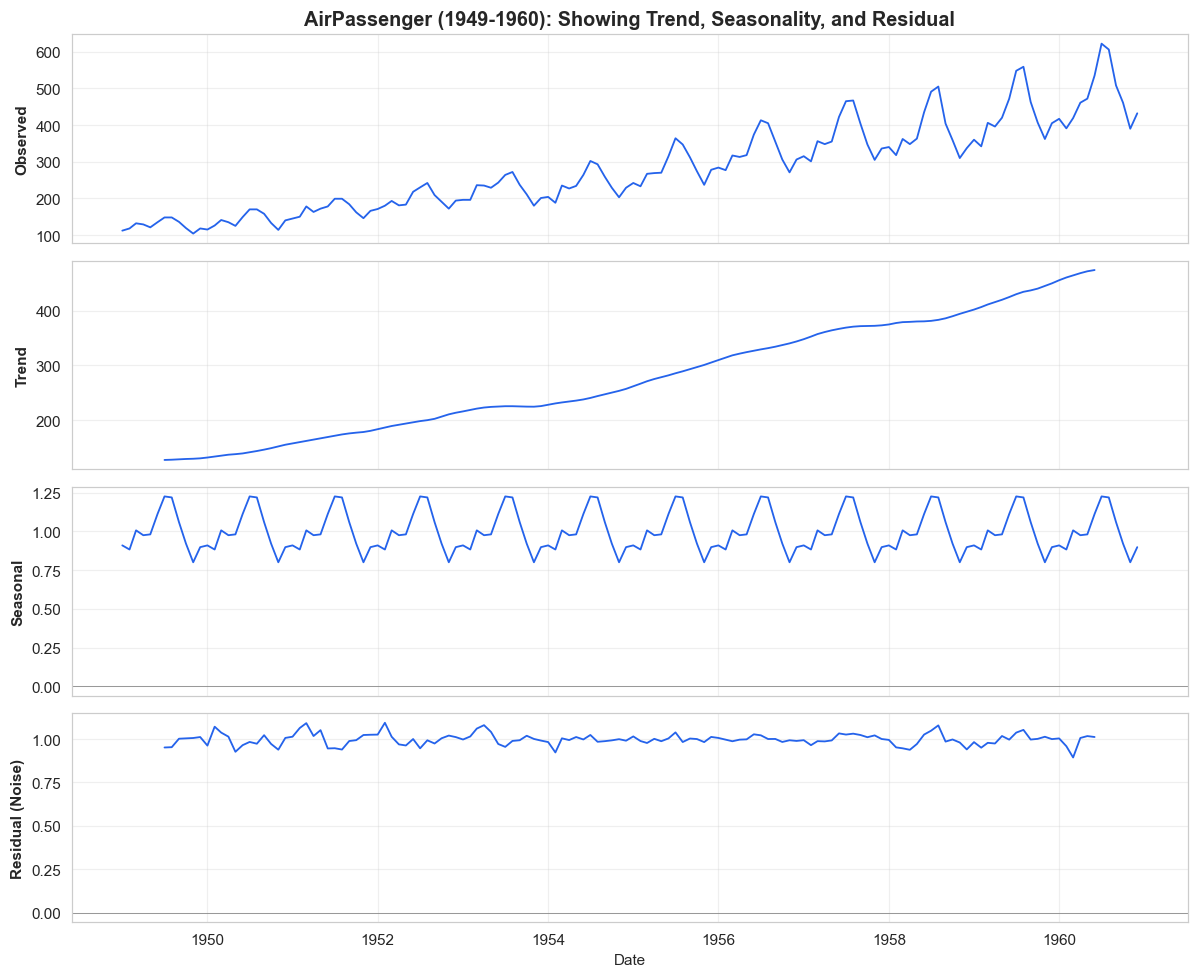

In [9]:
result_air = seasonal_decompose(air, model="multiplicative", period=12)
fig1 = plot_decomposition(result_air, "AirPassenger (1949-1960): Showing Trend, Seasonality, and Residual", color="#2563eb")